[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Pushups Rep Counter and Form Correction**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Project Overview

This project is an AI-powered fitness assistant that tracks pushup repetitions and evaluates exercise form in real time using a custom-trained **YOLO11 Pose Estimation** model.

The model predicts 33 body keypoints and monitors critical joints, including the shoulder, elbow, wrist, hip, and ankle, to analyze body posture throughout each repetition.

By calculating elbow and hip joint angles, the system simultaneously performs:

- **Pushup Repetition Counting** based on arm movement.
- **Real-Time Form Validation** by monitoring back and hip alignment.

If improper posture is detected, the system displays corrective feedback and pauses repetition counting until proper form is restored.

---

## Real-World Applications

### Home Fitness
Acts as a virtual personal trainer using only a smartphone or webcam.

### Physical Therapy
Monitors rehabilitation exercises and provides posture correction during recovery.

### Smart Gyms
Automatically tracks repetitions and exercise quality on smart mirrors or gym kiosks.

### Military & Sports Training
Standardizes pushup assessments with objective, AI-based form evaluation.

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 



## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.


In [1]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


In [2]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


## 🎞️ Random Frame Extraction from Video

Extracts a fixed number of high-quality frames from one or more videos to create an image dataset for annotation and training.

### 🔹 Purpose
- Convert raw manufacturing videos into individual image frames  
- Perform random sampling to avoid frame bias  
- Prepare data for annotation and YOLO training  


In [ ]:
%pip install tqdm

from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['4945123-uhd_4096_2160_24fps.mp4'],
    total_images=50,
    out_dir="dataset_Frames",
    jpg_quality=100,
    seed=42
)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[✓] Extracted 5 frames to folder: dataset_Frames


## 📥 Download Annotations from Labellerr

After completing data labeling on the **Labellerr** platform, export the annotations in **COCO JSON format**.

Download the COCO JSON file from the Labellerr website and upload it into this project workspace to use it for further dataset preparation and training.

This COCO JSON file will be used in the next steps for:
- Frame–annotation alignment
- COCO → YOLO format conversion
- Model training and evaluation


# COCO to YOLO Format Conversion

Converts COCO-style segmentation annotations to YOLO segmentation dataset format.  
- Requires: `annotation.json` and images in `frames_output` directory.
- Output: Generated YOLO dataset folder.
- Parameters: allows train/val split, shuffling, and verbose mode.


In [6]:
import json
import os
import random
from pathlib import Path

# Configuration - Updated image source path to your folder
JSON_PATH = 'c6e0bc81-30ac-42f1-8472-70ca5f16b178.json'
DATASET_ROOT = './yoloDataset'
IMAGE_SOURCE_DIR = './dataset_Frames'  # Points directly to your images folder

def setup_directories(root):
    """Creates the exact folder structure required by YOLO."""
    splits = ['train', 'val', 'test']
    for split in splits:
        os.makedirs(os.path.join(root, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(root, 'labels', split), exist_ok=True)

def convert_and_split(json_path, root_dir, img_src_dir, train_ratio=0.6, val_ratio=0.2):
    setup_directories(root_dir)

    # Load Labellerr export JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)

    images_list = data['images']
    
    # Shuffle to ensure a random distribution across splits
    random.seed(42)  
    random.shuffle(images_list)

    # Group annotations by image_id
    annotations_by_img = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_img:
            annotations_by_img[img_id] = []
        annotations_by_img[img_id].append(ann)

    total_images = len(images_list)
    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)

    for idx, img_info in enumerate(images_list):
        # Determine split assignment
        if idx < train_end:
            split = 'train'
        elif idx < val_end:
            split = 'val'
        else:
            split = 'test'

        img_w = img_info['width']
        img_h = img_info['height']
        file_name = img_info['file_name']

        txt_name = Path(file_name).with_suffix('.txt')
        
        target_img_path = os.path.join(root_dir, 'images', split, file_name)
        target_txt_path = os.path.join(root_dir, 'labels', split, txt_name)

        # 1. Move image from dataset_Frames folder to the new split folder
        source_img_path = os.path.join(img_src_dir, file_name)
        if os.path.exists(source_img_path):
            os.replace(source_img_path, target_img_path)
        else:
            print(f"Warning: Image {file_name} not found in '{img_src_dir}'. Only creating text label.")

        # 2. Convert and build the YOLO label lines
        annotations = annotations_by_img.get(img_info['id'], [])
        yolo_lines = []

        for ann in annotations:
            x_min, y_min, box_w, box_h = ann['bbox']
            x_center = (x_min + box_w / 2) / img_w
            y_center = (y_min + box_h / 2) / img_h
            norm_box_w = box_w / img_w
            norm_box_h = box_h / img_h

            class_idx = 0  # 'Body' maps to 0

            line_elements = [
                f"{class_idx}",
                f"{x_center:.6f}",
                f"{y_center:.6f}",
                f"{norm_box_w:.6f}",
                f"{norm_box_h:.6f}"
            ]

            kp_list = ann['keypoints']
            for i in range(0, len(kp_list), 3):
                kp_x = kp_list[i]
                kp_y = kp_list[i+1]
                kp_v = kp_list[i+2]

                norm_kp_x = kp_x / img_w if kp_v > 0 else 0.0
                norm_kp_y = kp_y / img_h if kp_v > 0 else 0.0
                line_elements.extend([f"{norm_kp_x:.6f}", f"{norm_kp_y:.6f}", f"{int(kp_v)}"])

            yolo_lines.append(" ".join(line_elements))

        # Write label text file
        with open(target_txt_path, 'w') as out_file:
            out_file.write("\n".join(yolo_lines))

    print(f"Dataset successfully created and split into {root_dir}!")

if __name__ == '__main__':
    convert_and_split(JSON_PATH, DATASET_ROOT, IMAGE_SOURCE_DIR)

Dataset successfully created and split into ./yoloDataset!


# Load and Train YOLO Pose Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
from ultralytics import YOLO

# 1. Load the pre-trained YOLO11 Large Pose model
# This automatically handles custom configurations defined in your data.yaml
model = YOLO('yolo11l-pose.pt') 

# 2. Kick off the training process on your dataset
model.train(
    data='/kaggle/working/data.yaml',    # Path to your data.yaml file in Kaggle
    epochs=100,                          # Number of training epochs
    imgsz=640,                           # Image size (YOLO standard pixel resolution)
    batch=16,                            # Batch size (adjust down to 8 if you hit GPU memory limits)
    project='/kaggle/working/factory',   # Directory where training logs/weights are saved
    name='train_run_11',                 # Name of this specific training execution run
    device=0                             # Uses the primary GPU (Kaggle T4 or P100)
)

# Single-Frame Pose Inference Pipeline

## Overview

This script performs single-frame inference using a custom-trained **YOLO11 Pose** model to visualize body keypoints on a selected video frame.

---

## Pipeline

### Target Frame Extraction
Loads the video and directly extracts **Frame 50**, then releases the video stream to minimize memory usage.

### Custom YOLO11 Inference
Runs the selected frame through the custom `best.pt` model with a confidence threshold of **0.5**.

### Pose Visualization
Uses the native `results[0].plot()` function to automatically render body keypoints and skeleton connections.

### Image Display
Converts the output from **BGR** to **RGB** and displays the annotated frame using Matplotlib with hidden axes.

---

Successfully predicted 33 keypoints on frame 50!


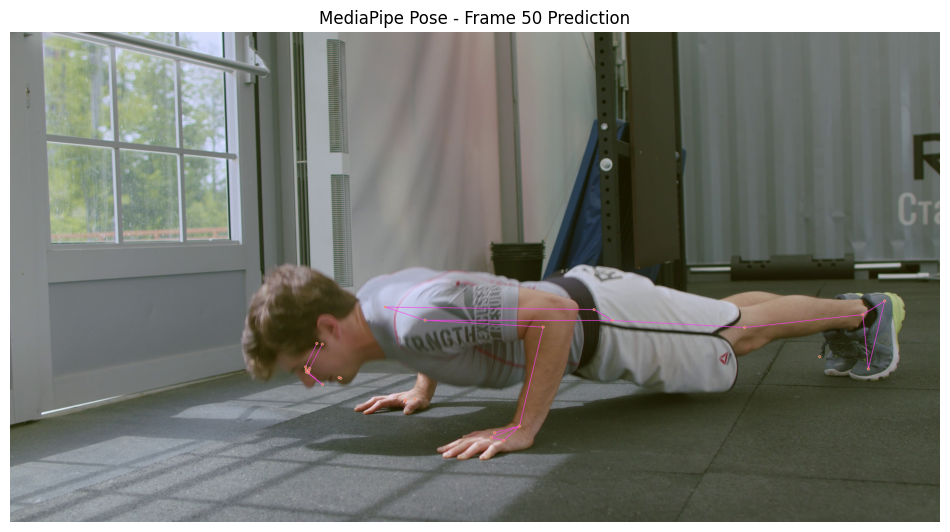

In [ ]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Configuration
VIDEO_PATH = '4945123-uhd_4096_2160_24fps.mp4' 
MODEL_PATH = 'best.pt'  
TARGET_FRAME = 50

def predict_and_display_yolo_frame(video_path, model_path, frame_number):
    # Load your custom trained YOLO11 pose model
    model = YOLO(model_path)
    
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return

    # Jump directly to the target frame index (0-based indexing)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number - 1)

    # Read the specific frame
    success, frame = cap.read()
    cap.release()  # Close video file immediately to free up memory

    if not success:
        print(f"Error: Could not read frame number {frame_number}.")
        return

    # Run your custom YOLO11 pose inference on the frame
    # conf=0.5 sets the minimum confidence threshold for detection
    results = model.predict(source=frame, conf=0.5, verbose=False)

    # Render the custom keypoints and bounding boxes onto the frame
    # results[0].plot() returns a standard BGR image array with annotations drawn
    annotated_frame_bgr = results[0].plot()

    # Convert BGR (OpenCV format) to RGB (Matplotlib requirement)
    annotated_frame_rgb = cv2.cvtColor(annotated_frame_bgr, cv2.COLOR_BGR2RGB)

    # Print detection summary in cell logs
    if len(results[0].boxes) > 0:
        print(f"Successfully detected {len(results[0].boxes)} person(s) with custom keypoints on frame {frame_number}!")
    else:
        print(f"No custom pose detected on frame {frame_number}.")

    # Display directly in the output cell using Matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')  # Hide pixel coordinate axes
    plt.title(f"YOLO11 Custom Pose - Frame {frame_number} Prediction")
    plt.show()

# Run the frame extraction and YOLO11 calculation
predict_and_display_yolo_frame(VIDEO_PATH, MODEL_PATH, TARGET_FRAME)

# Video Pose Inference Pipeline

## Overview

This script performs frame-by-frame inference using a custom-trained **YOLO11 Pose** model, overlays the predicted skeleton on each frame, and saves the annotated video.

---

## Pipeline

### Video Initialization
Loads the input video and retrieves its frame size and FPS.

### Video Writer
Creates an output video with the same resolution and frame rate as the source.

### Frame Processing
Processes each frame sequentially while displaying periodic progress updates.

### YOLO11 Pose Inference
Runs the custom `best.pt` model with a confidence threshold of **0.5** to detect body keypoints.

### Skeleton Rendering
Uses `results[0].plot()` to automatically draw keypoints and skeletal connections on every frame.

### Export
Writes the annotated frames to the output video and releases all resources after processing.

---

In [ ]:
import cv2
from ultralytics import YOLO

# Configuration
VIDEO_PATH = '4945123-uhd_4096_2160_24fps.mp4'
OUTPUT_PATH = 'raw inference.mp4'
MODEL_PATH = 'best.pt'

def process_entire_video(video_path, output_path, model_path):
    # Load your custom trained YOLO11 pose model
    model = YOLO(model_path)
    
    # Open the source video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return

    # Extract video properties for the writer configuration
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Processing Video: {width}x{height} @ {fps} FPS | Total Frames: {total_frames}")

    # Initialize VideoWriter (mp4v codec)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break  # Video is finished or frame dropped

        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processing frame {frame_count}/{total_frames}...")

        # Run custom YOLO11 pose inference directly on the raw BGR frame
        # stream=True optimizes memory management when processing large/long videos
        results = model.predict(source=frame, conf=0.5, verbose=False, stream=False)

        # Draw your custom bounding boxes and 33 keypoint skeleton automatically
        annotated_frame = results[0].plot()

        # Write the annotated frame out to our file stream
        out.write(annotated_frame)

    # Clean up operations
    cap.release()
    out.release()
    print(f"\nProcessing complete! Video saved successfully as: '{output_path}'")

if __name__ == '__main__':
    process_entire_video(VIDEO_PATH, OUTPUT_PATH, MODEL_PATH)

Processing Video: 4096x2160 @ 24.0 FPS | Total Frames: 445
Processing frame 30/445...
Processing frame 60/445...
Processing frame 90/445...
Processing frame 120/445...
Processing frame 150/445...
Processing frame 180/445...
Processing frame 210/445...
Processing frame 240/445...
Processing frame 270/445...
Processing frame 300/445...
Processing frame 330/445...
Processing frame 360/445...
Processing frame 390/445...
Processing frame 420/445...

Processing complete! Video saved successfully as: 'raw inference.mp4'


# Pushup Analysis & Repetition Engine

## Overview

This script performs real-time pushup analysis using a custom-trained **YOLO11 Pose** model. It detects body keypoints, computes joint angles, validates posture, counts repetitions, and displays live feedback through an interactive dashboard.

---

## Core Components

### YOLO11 Pose Estimation
Uses the custom `best.pt` model to detect 33 body keypoints and continuously track the shoulder, elbow, wrist, hip, and ankle throughout the exercise.

### Joint Angle Calculation
Calculates the **elbow** and **hip** angles using vector geometry (`arctan2`) to measure arm flexion and body alignment. The computed angle is normalized to the range **0°–180°** for consistent measurements.

### Posture Validation
Monitors the hip angle to verify a straight body posture. If the body angle falls outside the **160°–200°** range, the system displays a **"Fix Back Alignment!"** warning and temporarily pauses repetition counting.

### Repetition Counter
Uses a finite-state machine to detect **UP** and **DOWN** pushup stages based on the elbow angle:
- **UP:** Elbow angle > 160°
- **DOWN:** Elbow angle < 90°

A repetition is counted only when a valid **UP → DOWN** transition occurs while maintaining proper posture.

### Live Visualization
Displays the predicted skeleton, joint angle values, repetition count, posture status, and a real-time HUD directly on the video.

---

## Angle Logic

The system computes joint angles using three body keypoints, where the middle point acts as the vertex.

- **Elbow Angle:** Shoulder → Elbow → Wrist  
  Used to determine pushup progression and repetition counting.

- **Hip Angle:** Shoulder → Hip → Ankle  
  Used to evaluate back alignment and detect poor posture.

The angle is calculated using vector mathematics and normalized to the internal joint angle. This provides stable and accurate measurements regardless of the user's position within the frame.

---

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# Configuration
VIDEO_PATH = '4945123-uhd_4096_2160_24fps.mp4'
OUTPUT_PATH = 'pushup_counter_yolo11.mp4'
MODEL_PATH = 'best.pt'  # Update this to your trained best.pt location

def calculate_angle(a, b, c):
    """Calculates the angle between three points (b is the vertex)."""
    a = np.array(a) # Point 1
    b = np.array(b) # Vertex (Elbow / Hip)
    c = np.array(c) # Point 3
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle

def process_pushups_yolo(video_path, output_path, model_path):
    # Load your custom trained YOLO11 pose model
    model = YOLO(model_path)
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # State tracking variables
    counter = 0
    stage = None  # "down" or "up"
    posture_feedback = "Correct"
    
    # Define mapping index based on your 33 keypoints configuration from your categories list:
    # 11: left_shoulder, 12: right_shoulder, 13: left_elbow, 15: left_wrist, 23: left_hip, 27: left_ankle
    LEFT_SHOULDER_IDX = 11
    LEFT_ELBOW_IDX    = 13
    LEFT_WRIST_IDX    = 15
    LEFT_HIP_IDX      = 23
    LEFT_ANKLE_IDX    = 27

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
        
        # Run inference using your custom model
        results = model.predict(source=frame, conf=0.5, verbose=False)
        
        # Check if any person is detected with keypoints
        if len(results) > 0 and results[0].keypoints is not None:
            # Get pixel coordinates directly mapping to your frame dimensions: shape [num_persons, num_keypoints, 2]
            kpts = results[0].keypoints.xy.cpu().numpy()
            
            # Make sure at least one person's keypoint structure is detected
            if len(kpts) > 0 and len(kpts[0]) > max(LEFT_HIP_IDX, LEFT_ANKLE_IDX):
                person_kpts = kpts[0] # Focus on the primary person detected
                
                # Extract (x, y) coordinates
                shoulder = person_kpts[LEFT_SHOULDER_IDX]
                elbow    = person_kpts[LEFT_ELBOW_IDX]
                wrist    = person_kpts[LEFT_WRIST_IDX]
                hip      = person_kpts[LEFT_HIP_IDX]
                ankle    = person_kpts[LEFT_ANKLE_IDX]
                
                # Verify that keypoint arrays aren't unlocalized zeros [0., 0.]
                if all(np.sum(pt) > 0 for pt in [shoulder, elbow, wrist, hip, ankle]):
                    
                    # Convert to integer pixel coordinates for rendering text
                    shoulder_pt = (int(shoulder[0]), int(shoulder[1]))
                    elbow_pt    = (int(elbow[0]), int(elbow[1]))
                    wrist_pt    = (int(wrist[0]), int(wrist[1]))
                    hip_pt      = (int(hip[0]), int(hip[1]))
                    ankle_pt    = (int(ankle[0]), int(ankle[1]))
                    
                    # Compute tracking angles
                    elbow_angle = calculate_angle(shoulder, elbow, wrist)
                    body_angle = calculate_angle(shoulder, hip, ankle)
                    
                    # 1. Posture Check
                    if body_angle < 160.0 or body_angle > 200.0:
                        posture_feedback = "Fix Back Alignment!"
                        color_box = (0, 0, 255) # Red
                    else:
                        posture_feedback = "Good Posture"
                        color_box = (0, 255, 0) # Green
                    
                    # 2. Counter Logic
                    if elbow_angle > 160:
                        stage = "up"
                    if elbow_angle < 90 and stage == 'up':
                        stage = "down"
                        if posture_feedback == "Good Posture":
                            counter += 1
                    
                    # Draw YOLO native skeletal lines and bounding boxes automatically
                    frame = results[0].plot()
                    
                    # --- ENLARGED TOP-LEFT HUD DISPLAY BOX ---
                    cv2.rectangle(frame, (20, 20), (750, 360), color_box, -1)
                    
                    # HUD Text overlays with heavy font scale and thickness
                    cv2.putText(frame, f"REPS: {counter}", (45, 95), 
                                cv2.FONT_HERSHEY_SIMPLEX, 2.5, (0, 0, 0), 6, cv2.LINE_AA)
                    cv2.putText(frame, f"STAGE: {stage.upper() if stage else 'N/A'}", (45, 165), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 0, 0), 4, cv2.LINE_AA)
                    cv2.putText(frame, f"POSTURE: {posture_feedback}", (45, 230), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.4, (0, 0, 0), 4, cv2.LINE_AA)
                    cv2.putText(frame, f"Elbow: {elbow_angle:.1f} deg | Hip: {body_angle:.1f} deg", (45, 305), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (50, 50, 50), 3, cv2.LINE_AA)
                    
                    # --- LIVE DYNAMIC LABELS NEAR KEYPOINTS ---
                    # Left Elbow Angle Text Placement
                    cv2.putText(frame, f"{int(elbow_angle)} deg", (elbow_pt[0] + 30, elbow_pt[1] - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 4, cv2.LINE_AA)
                    cv2.putText(frame, f"{int(elbow_angle)} deg", (elbow_pt[0] + 30, elbow_pt[1] - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2, cv2.LINE_AA)

                    # Left Hip Angle Text Placement
                    cv2.putText(frame, f"{int(body_angle)} deg", (hip_pt[0] + 30, hip_pt[1] - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 4, cv2.LINE_AA)
                    cv2.putText(frame, f"{int(body_angle)} deg", (hip_pt[0] + 30, hip_pt[1] - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 2, cv2.LINE_AA)
                    
        out.write(frame)
        
    cap.release()
    out.release()
    print(f"Tracking complete! Video saved using custom YOLO11 model as: {output_path}")

if __name__ == '__main__':
    process_pushups_yolo(VIDEO_PATH, OUTPUT_PATH, MODEL_PATH)

Tracking complete! High-visibility video saved as: pushup_counter.mp4


---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
